In [1]:

!pip install pyinaturalist
!pip install autodistill_grounding_dino 
!pip install autodistill
!pip install roboflow
!pip install transformers==4.39.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.1/141.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.4/82.4 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.1/377.1 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 22.0 MB/s eta 0:00:00
  Created wheel for rf-groundingdino: filename=rf_groundingdino-0.1.2-py2.py3-none-any.whl size=88807 sha256=ef04a3093a36645104fdd1d31058475ca630afbe06937d8b0c00

In [2]:
import transformers
print(transformers.__version__) # This will print 4.39.3

4.39.3


In [3]:
import os
import requests
from pyinaturalist import get_observations

SPECIES_TAXON_IDS = {
    'arabian_oryx': 42309,
    'reem_gazelle': 568725  
}

# In Kaggle, this saves to /kaggle/working/raw_desert_wildlife_data
OUTPUT_DIR = "./raw_desert_wildlife_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for species_name, taxon_id in SPECIES_TAXON_IDS.items():
    species_dir = os.path.join(OUTPUT_DIR, species_name)
    os.makedirs(species_dir, exist_ok=True)
    
    # Fetch observation records
    observations = get_observations(
        taxon_id=taxon_id,
        quality_grade='research',
        photos=True,
        page=1,
        per_page=200
    )
    
    download_count = 0
    # pyinaturalist returns a list directly
    results = observations.get('results', []) if isinstance(observations, dict) else observations
    
    for obs in results:
        # Check both dict and object access patterns for compatibility
        photos = obs.get('observation_photos', []) if isinstance(obs, dict) else getattr(obs, 'observation_photos', [])
        
        for photo_item in photos:
            photo = photo_item.get('photo', {}) if isinstance(photo_item, dict) else getattr(photo_item, 'photo', {})
            url = photo.get('url') if isinstance(photo, dict) else getattr(photo, 'url', None)
            photo_id = photo.get('id') if isinstance(photo, dict) else getattr(photo, 'id', None)
            
            if not url or not photo_id:
                continue
                
            photo_url = url.replace('square', 'large')
            file_path = os.path.join(species_dir, f"{species_name}_{photo_id}.jpg")
            
            if not os.path.exists(file_path):
                try:
                    response = requests.get(photo_url, stream=True, timeout=10)
                    if response.status_code == 200:
                        with open(file_path, 'wb') as handler:
                            for chunk in response.iter_content(chunk_size=8192):
                                handler.write(chunk)
                        download_count += 1
                except Exception as e:
                    print(f"Failed to download {photo_url}: {e}")

    print(f"Downloaded {download_count} new images for {species_name}.")

Downloaded 345 new images for arabian_oryx.
Downloaded 358 new images for reem_gazelle.


In [4]:
import os
import shutil
from autodistill_grounding_dino import GroundingDINO
from autodistill.detection import CaptionOntology

# 1. تعريف قاموس الأوصاف المخصصة لكل فئة
SPECIES_CONFIG = {
    'arabian_oryx': {
        'prompt': "white oryx with long straight horns",
        'label': "arabian_oryx"
    },
    'reem_gazelle': {
        'prompt': "sand gazelle",
        'label': "reem_gazelle"
    }
}

base_raw_dir = "./raw_desert_wildlife_data"
final_dataset_dir = "./yolo_annotated_dataset"

# 2. المرور على مجلد كل حيوان وتوسيمه بشكل مستقل
for species_folder, config in SPECIES_CONFIG.items():
    folder_path = os.path.join(base_raw_dir, species_folder)
    
    if not os.path.exists(folder_path) or len(os.listdir(folder_path)) == 0:
        continue
        
    print(f"جاري توسيم صور {species_folder}...")

Importing from timm.models.layers is deprecated, please import via timm.layers


جاري توسيم صور arabian_oryx...
جاري توسيم صور reem_gazelle...


In [5]:
# بناء ontology خصيصاً لهذا المجلد
ontology = CaptionOntology({
    config['prompt']: config['label']
})

# تهيئة النموذج بعتبة ثقة مناسبة
base_model = GroundingDINO(
    ontology=ontology,
    box_threshold=0.35,
    text_threshold=0.25
)

trying to load grounding dino directly
downloading dino model weights


torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)


final text_encoder_type: bert-base-uncased


`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [6]:
# توسيم مجلد الفئة الحالية
temp_output = f"./temp_annotated_{species_folder}"
base_model.label(
    input_folder=folder_path,
    extension=".jpg",
    output_folder=temp_output
)

print("تم توسيم جميع الفئات بنجاح!")

Labeling ./raw_desert_wildlife_data/reem_gazelle/reem_gazelle_453680635.jpg:   0%|          | 0/358 [00:00<?, ?it/s]The `device` argument is deprecated and will be removed in v5 of Transformers.
torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
None of the inputs have requires_grad=True. Gradients will be None
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
Labeling ./raw_desert_wildlife_data/reem_gazelle/reem_gazelle_491697694.jpg: 100%|██████████| 358/358 [03:16<00:00,  1.82it/s]


Labeled dataset created - ready for distillation.
تم توسيم جميع الفئات بنجاح!


In [7]:
import os
import shutil
from glob import glob

final_dataset_dir = "./yolo_annotated_dataset"
for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(final_dataset_dir, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(final_dataset_dir, split, 'labels'), exist_ok=True)


temp_folders = glob("./temp_annotated_*")

for temp_dir in temp_folders:
    for split in ['train', 'valid', 'test']:
        img_src = os.path.join(temp_dir, split, 'images')
        lbl_src = os.path.join(temp_dir, split, 'labels')
        
        if os.path.exists(img_src):
            for img_file in os.listdir(img_src):
                shutil.move(os.path.join(img_src, img_file), os.path.join(final_dataset_dir, split, 'images', img_file))
                
        if os.path.exists(lbl_src):
            for lbl_file in os.listdir(lbl_src):
                shutil.move(os.path.join(lbl_src, lbl_file), os.path.join(final_dataset_dir, split, 'labels', lbl_file))
                

    shutil.rmtree(temp_dir)



In [8]:
import yaml

yaml_data = {
    'path': '/kaggle/working/yolo_annotated_dataset',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 2,
    'names': [ 'arabian_oryx', 'reem_gazelle']
}

with open('/kaggle/working/corrected_data.yaml', 'w') as f:
    yaml.dump(yaml_data, f)

In [9]:
!pip install ultralytics -q

from ultralytics import YOLO


model = YOLO('yolo11m.pt')

results = model.train(
    data='/kaggle/working/corrected_data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    freeze=20,
    project='/kaggle/working/runs',                     
    name='desert_wildlife',
    conf=0.25,      
    iou=0.45,       
    single_cls=False  
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 6.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.145 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/corrected_data.yaml, de

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


      2/100      6.78G      1.057      1.286      1.242         39        640: 100% ━━━━━━━━━━━━ 18/18 4.5it/s 4.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.5it/s 0.9s
                   all         72        114     0.0513      0.921     0.0474     0.0266

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      6.78G      1.072      1.252        1.3         44        640: 100% ━━━━━━━━━━━━ 18/18 4.5it/s 4.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.5it/s 0.9s
                   all         72        114     0.0515      0.912     0.0512     0.0286

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100      6.78G      1.014     0.9706      1.283         39        640: 100% ━━━━━━━━━━━━ 18/18 4.5it/s 4.0s
                 Class     Images  Instances      Box(P          R

In [10]:
from ultralytics import YOLO

# Load your trained model weights (saved automatically in the runs directory)
model = YOLO('//kaggle/working/runs/desert_wildlife/weights/best.pt')

results = model(
    #/kaggle/input/datasets/abdulrhman211/testss/Arabian_sand.jpg  <-  test
    #/kaggle/input/datasets/abdulrhman211/testss/oryx.jpg   <- test
    source='/kaggle/input/datasets/abdulrhman211/testss/oryx.jpg',
    conf=0.85,  # Confidence threshold (adjust as needed)
    save=True   # Save the results with bounding boxes to runs/detect/predict
)


image 1/1 /kaggle/input/datasets/abdulrhman211/testss/oryx.jpg: 320x640 1 arabian_oryx, 10.5ms
Speed: 1.5ms preprocess, 10.5ms inference, 1.4ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /kaggle/working/runs/detect/predict


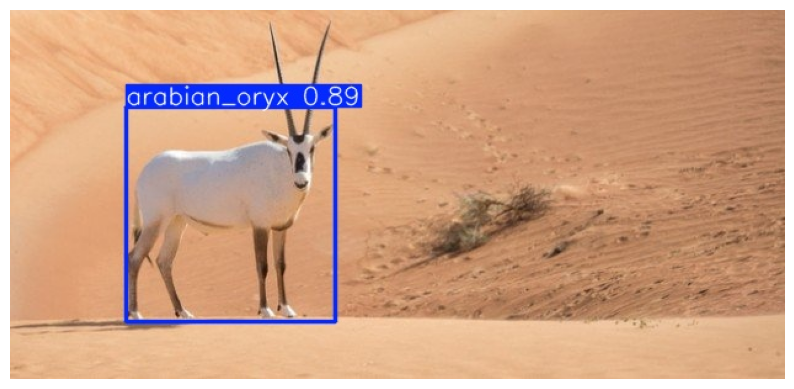

In [11]:
import matplotlib.pyplot as plt
import cv2
import glob
import os

# Find the latest prediction folder generated by YOLO
latest_predict_dir = max(glob.glob('/kaggle/working/runs/detect/predict*'), key=os.path.getmtime)
predicted_images = glob.glob(f"{latest_predict_dir}/*.jpg")

if predicted_images:
    # Read the first predicted image
    img_path = predicted_images[0]
    img = cv2.imread(img_path)
    
    # OpenCV loads images in BGR format, convert to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Plot using matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print("No prediction images found yet. Make sure to run model(source=...) first!")

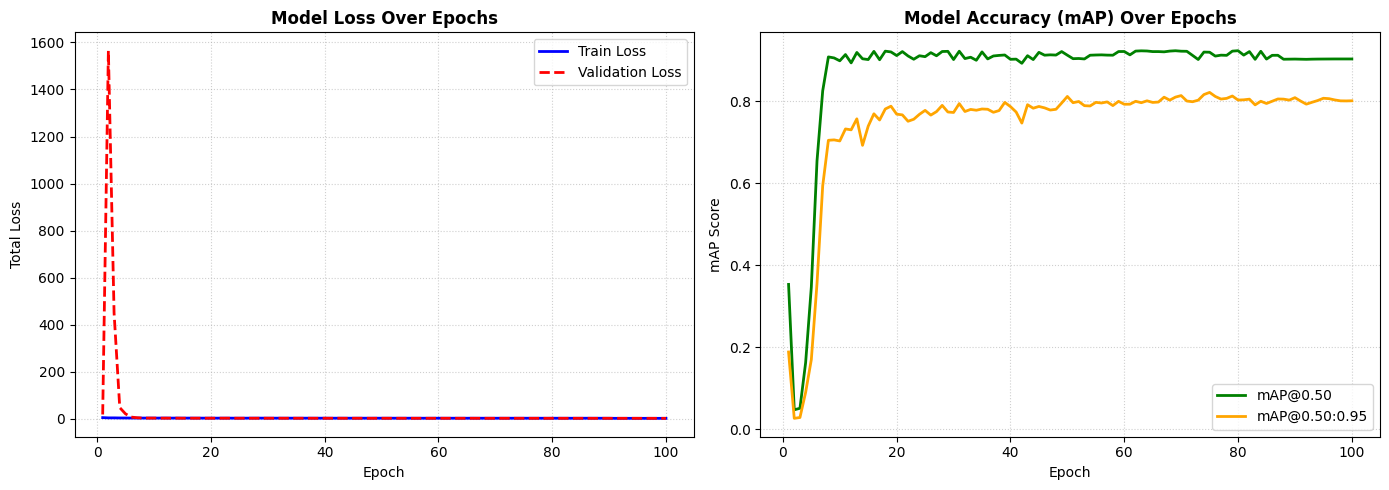

In [12]:
import pandas as pd



csv_path = "/kaggle/working/runs/desert_wildlife/results.csv"

# 2. قراءة ملف csv الذي يحتوي على تفاصيل كل Epoch
df = pd.read_csv(csv_path)

# تنظيف أسماء الأعمدة من المسافات الزائدة
df.columns = df.columns.str.strip()

# 3. إنشاء شكل الرسم البياني (Figure)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- الرسم الأول: الخطأ (Loss) ---
# تجميع خطأ التدريب والتحقق (Train & Val Loss)
train_loss = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
val_loss = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']

axes[0].plot(df['epoch'], train_loss, label='Train Loss', color='blue', linewidth=2)
axes[0].plot(df['epoch'], val_loss, label='Validation Loss', color='red', linestyle='--', linewidth=2)
axes[0].set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=10)
axes[0].set_ylabel('Total Loss', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# --- الرسم الثاني: الدقة (mAP50 & mAP50-95) ---
axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.50', color='green', linewidth=2)
axes[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.50:0.95', color='orange', linewidth=2)
axes[1].set_title('Model Accuracy (mAP) Over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=10)
axes[1].set_ylabel('mAP Score', fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()